# Pleo RevOps — Weekly GTM Performance Review

**Analyst:** Daniel Amezquita  
**As of:** 2026-05-14 (Q2 2026, week 7)  
**Audience:** CRO, VP Sales, RevOps, Finance

Every figure below queries the dbt marts in DuckDB. The dashboard pulls from the same marts.

**Sections**
1. Q2 ARR pace
2. Pipeline quality — stalled · slipped · velocity · ASP
3. Quality flags (the call list)
4. Funnel conversion by stage
5. Rep performance vs target
6. Pipeline velocity (avg days per stage)
7. Pipeline efficiency (slippage, close-date drift)
8. Automation opportunity
9. Data quality drift

In [1]:
import duckdb, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DBT_DB = Path('/tmp/pleo.duckdb')
FIG_DIR = Path('../dashboard/assets'); FIG_DIR.mkdir(parents=True, exist_ok=True)
con = duckdb.connect(str(DBT_DB), read_only=True)
AS_OF = pd.Timestamp('2026-05-14')

PLEO = {
    'black': '#000000', 'yellow': '#fcea88', 'green': '#ace3bd',
    'purple': '#a69ae3', 'pink': '#f39ca8', 'positive': '#2c8354',
    'negative': '#e91c1c', 'warning': '#dbbd1a', 'text': '#333333',
    'grey': '#cccccc'
}
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white'
})

def q(sql): return con.execute(sql).df()
def save_fig(name):
    plt.tight_layout(); plt.savefig(FIG_DIR / f'{name}.png', dpi=144, bbox_inches='tight'); plt.show()

## 1. Q2 2026 ARR pace

In [2]:
q2 = q("""
  select quarter, sum(target_eur) target_eur, sum(closed_arr_eur) closed_eur
  from main_marts.fct_quarterly_arr
  where quarter in ('Q3 2025', 'Q4 2025', 'Q1 2026', 'Q2 2026')
  group by 1 order by 1
""")
q2['attainment_pct'] = q2['closed_eur'] / q2['target_eur'] * 100
q2['gap_eur'] = q2['closed_eur'] - q2['target_eur']
q2

,quarter,target_eur,closed_eur,attainment_pct,gap_eur
0,Q1 2026,480000.0,117000.0,24.375000,-363000.0
1,Q2 2026,310600.0,0.0,0.000000,-310600.0
2,Q3 2025,480000.0,157000.0,32.708333,-323000.0
3,Q4 2025,480000.0,24000.0,5.000000,-456000.0


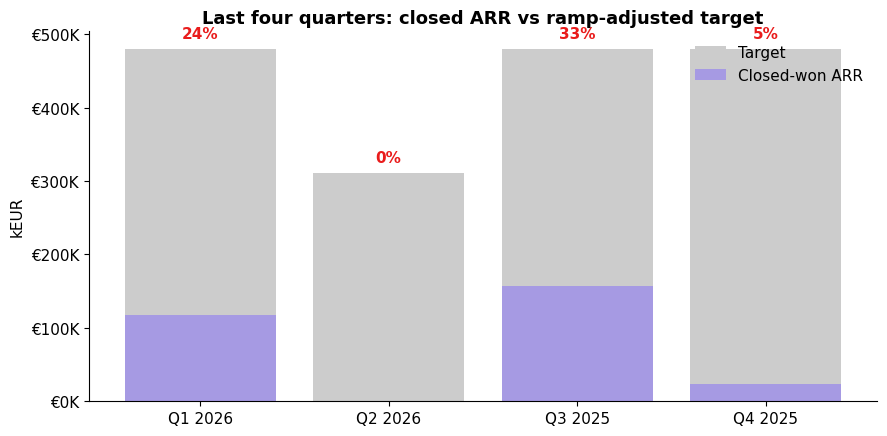

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = q2['quarter']
ax.bar(x, q2['target_eur'] / 1000, color=PLEO['grey'], label='Target')
ax.bar(x, q2['closed_eur'] / 1000, color=PLEO['purple'], label='Closed-won ARR')
for i, row in q2.iterrows():
    pct = row['attainment_pct']
    color = PLEO['negative'] if pct < 50 else (PLEO['warning'] if pct < 90 else PLEO['positive'])
    ax.text(i, row['target_eur']/1000 + 15, f'{pct:.0f}%', ha='center', fontweight='bold', color=color)
ax.set_title('Last four quarters: closed ARR vs ramp-adjusted target')
ax.set_ylabel('kEUR'); ax.legend(loc='upper right', frameon=False)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'€{v:.0f}K'))
save_fig('q2_pace')

In [4]:
# Q2 pipeline upside check
q2_pipe_total = q("""
  select sum(arr_eur) arr_eur, sum(weighted_arr_eur) weighted_eur, count(*) deals
  from main_marts.fct_pipeline_health where closes_in_q2_2026
""").iloc[0]
print(f"Q2 pipeline: €{q2_pipe_total['arr_eur']/1000:.0f}K gross / €{q2_pipe_total['weighted_eur']/1000:.0f}K weighted across {int(q2_pipe_total['deals'])} deals")
print(f"Even at full conversion of the weighted pipeline, Q2 gap is €{(310600 - q2_pipe_total['weighted_eur'])/1000:.0f}K")

Q2 pipeline: €854K gross / €255K weighted across 28 deals
Even at full conversion of the weighted pipeline, Q2 gap is €55K


## 2. Pipeline quality — stalled · slipped · velocity · ASP

Four signals the VP of Sales should track every Monday.

In [5]:
headline = q("""
  select
    -- Stalled
    (select count(*) from main_marts.fct_pipeline_health where is_stale)                          as stalled_deals,
    (select sum(arr_eur) from main_marts.fct_pipeline_health where is_stale)                      as stalled_arr,
    -- Slipped (close date moved out at last snapshot)
    (select count(*) from main_marts.fct_pipeline_health where close_date_slippage_days > 0)      as slipped_deals,
    (select sum(arr_eur) from main_marts.fct_pipeline_health where close_date_slippage_days > 0)  as slipped_arr,
    -- Velocity (avg sales cycle of won deals, last 12m)
    (select avg(sales_cycle_days) from main_marts.fct_opportunities
     where is_won and opp_created_date >= date '2025-05-01' and sales_cycle_days > 0)             as avg_cycle_days,
    -- ASP (avg sale price of won deals, last 12m)
    (select avg(arr_eur) from main_marts.fct_opportunities
     where is_won and close_date >= date '2025-05-01')                                            as asp_eur
""").iloc[0]
print(f"Stalled:       {int(headline['stalled_deals'])} deals · €{headline['stalled_arr']/1000:.0f}K")
print(f"Slipped:       {int(headline['slipped_deals'])} deals · €{headline['slipped_arr']/1000:.0f}K (last snapshot)")
print(f"Avg cycle:     {headline['avg_cycle_days']:.0f} days (won, last 12m)")
print(f"ASP:           €{headline['asp_eur']:,.0f} (won, last 12m)")

Stalled:       34 deals · €1341K
Slipped:       9 deals · €405K (last snapshot)
Avg cycle:     2 days (won, last 12m)
ASP:           €74,500 (won, last 12m)


In [6]:
asp_by_source = q("""
  select demand_source, count(*) won_deals,
         round(avg(arr_eur), 0) asp_eur,
         round(sum(arr_eur), 0) total_eur
  from main_marts.fct_opportunities
  where is_won
  group by 1 order by asp_eur desc
""")
asp_by_source

,demand_source,won_deals,asp_eur,total_eur
0,Partnerships,5,93600.0,468000.0
1,Marketing,5,68000.0,340000.0
2,SDR Outbound,5,32200.0,161000.0
3,AE Outbound,3,31667.0,95000.0


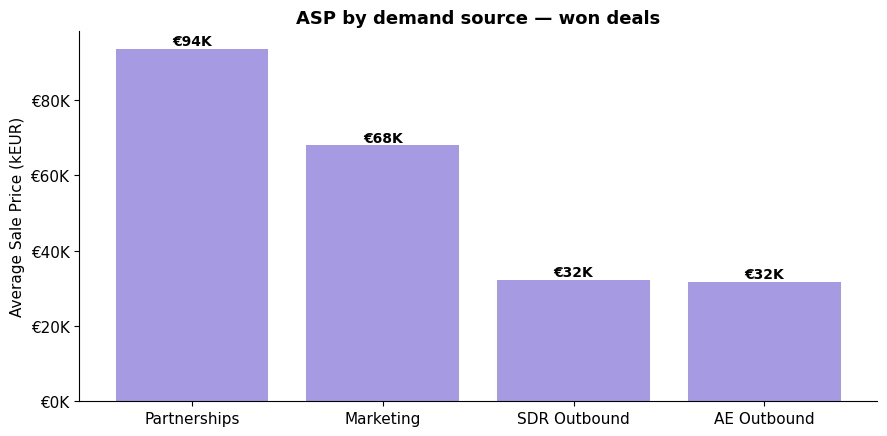

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(asp_by_source['demand_source'], asp_by_source['asp_eur']/1000, color=PLEO['purple'])
for i, v in enumerate(asp_by_source['asp_eur']):
    ax.text(i, v/1000 + 1, f'€{v/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
ax.set_title('ASP by demand source — won deals')
ax.set_ylabel('Average Sale Price (kEUR)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'€{v:.0f}K'))
save_fig('asp_by_source')

## 3. Quality flags — the call list

Same pattern as the reference GTM suite: every flag has a deal count, ARR, and an owner.

In [8]:
flags = q("""
  select 'Stalled > 30d no activity' as flag,
         count(*) deals, sum(arr_eur)/1000 arr_kEUR, 'Sales lead' as flag_owner
    from main_marts.fct_pipeline_health where is_stale
  union all
  select 'Slipped close date',
    count(*) filter (where close_date_slippage_days > 0),
    sum(arr_eur) filter (where close_date_slippage_days > 0)/1000, 'Sales lead' as flag_owner
    from main_marts.fct_pipeline_health
  union all
  select 'Deals > 90d in stage',
    count(*) filter (where stage_age_days > 90),
    sum(arr_eur) filter (where stage_age_days > 90)/1000, 'Sales lead' as flag_owner
    from main_marts.fct_pipeline_health
  union all
  select 'No activity ever logged',
    count(*) filter (where last_activity_date is null),
    coalesce(sum(arr_eur) filter (where last_activity_date is null)/1000, 0), 'RevOps' as flag_owner
    from main_marts.fct_pipeline_health
  order by arr_kEUR desc nulls last
""")
flags

,flag,deals,arr_kEUR,flag_owner
0,Stalled > 30d no activity,34,1341.0,Sales lead
1,Deals > 90d in stage,23,785.0,Sales lead
2,Slipped close date,9,405.0,Sales lead
3,No activity ever logged,0,0.0,RevOps


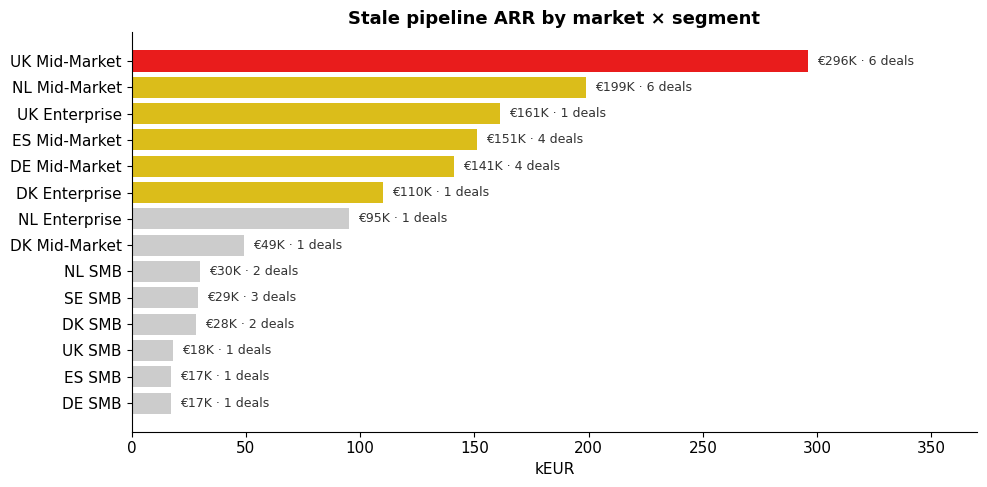

In [9]:
stale_by_seg = q("""
  select market, segment, count(*) deals, sum(arr_eur)/1000 arr_kEUR
  from main_marts.fct_pipeline_health where is_stale
  group by 1, 2 order by arr_kEUR desc
""")
fig, ax = plt.subplots(figsize=(10, 5))
labels = stale_by_seg['market'] + ' ' + stale_by_seg['segment']
colors = [PLEO['negative'] if x > 200 else (PLEO['warning'] if x > 100 else PLEO['grey']) for x in stale_by_seg['arr_kEUR']]
ax.barh(labels, stale_by_seg['arr_kEUR'], color=colors)
for i, v in enumerate(stale_by_seg['arr_kEUR']):
    ax.text(v + 4, i, f'€{v:.0f}K · {stale_by_seg["deals"].iloc[i]} deals', va='center', fontsize=9, color=PLEO['text'])
ax.invert_yaxis()
ax.set_title('Stale pipeline ARR by market × segment'); ax.set_xlabel('kEUR')
ax.set_xlim(0, stale_by_seg['arr_kEUR'].max() * 1.25)
save_fig('stale_by_segment')

In [10]:
top_stale = q("""
  select account_name, rep_name, market, segment, stage,
         round(arr_eur/1000,1) arr_kEUR, days_since_last_activity as days_silent
  from main_marts.fct_pipeline_health where is_stale order by arr_eur desc limit 12
""")
top_stale

,account_name,rep_name,market,segment,stage,arr_kEUR,days_silent
0,Wise,J. Patel,UK,Enterprise,Qualified,161.0,85
1,Klarna,E. Lindqvist,DK,Enterprise,Evaluation,110.0,43
2,Adyen,F. Jacobs,NL,Enterprise,Initial Meeting,95.0,103
3,Wolt,N. Walsh,UK,Mid-Market,Contracting,59.0,70
4,Wolt,S. Andersen,UK,Mid-Market,Discovery,58.0,49
5,GetYourGuide,N. Weber,DE,Mid-Market,Contracting,58.0,101
6,Remote,M. Eriksson,UK,Mid-Market,Negotiation,57.0,33
7,Omio,J. Patel,UK,Mid-Market,Discovery,53.0,34
8,Jobandtalent,O. Svensson,ES,Mid-Market,Initial Meeting,52.0,62
9,Kry,E. Lindqvist,DK,Mid-Market,Qualified,49.0,48


## 4. Funnel conversion · by stage

Trailing 13 weeks (Feb 2026 onwards) — the cohort closest to the current pacing problem.

In [11]:
funnel = q("""
  select sum(leads) leads, sum(mqls) mqls, sum(sqls) sqls,
         sum(demos) demos, sum(opps) opps, sum(won) won, sum(lost) lost
  from main_marts.fct_funnel_conversion where event_month >= date '2026-02-01'
""").iloc[0]
funnel

leads    14.0
mqls      9.0
sqls      8.0
demos     5.0
opps      1.0
won       1.0
lost      1.0
Name: 0, dtype: float64

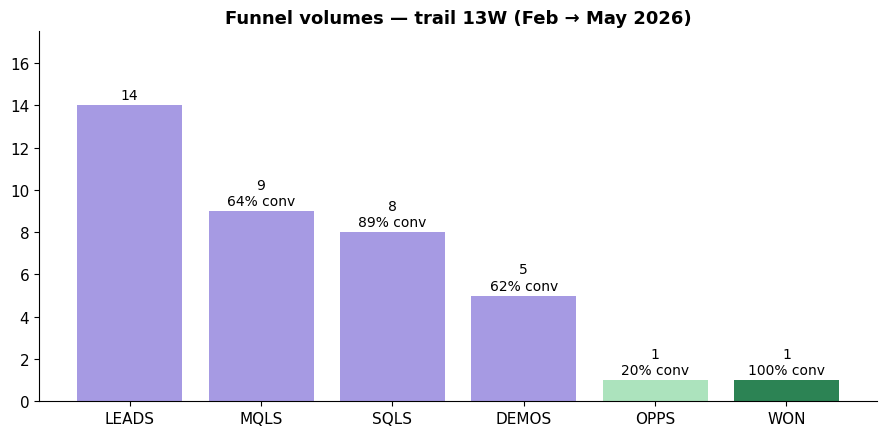

In [12]:
stages = ['leads', 'mqls', 'sqls', 'demos', 'opps', 'won']
vals = [int(funnel[c]) for c in stages]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([s.upper() for s in stages], vals, color=[PLEO['purple']]*4 + [PLEO['green'], PLEO['positive']])
for i, v in enumerate(vals):
    label = f'{v}'
    if i > 0 and vals[i-1] > 0:
        label += f'\n{vals[i]/vals[i-1]*100:.0f}% conv'
    ax.text(i, v + max(vals)*0.02, label, ha='center', fontsize=10)
ax.set_title('Funnel volumes — trail 13W (Feb → May 2026)')
ax.set_ylim(0, max(vals)*1.25)
save_fig('funnel_volumes')

In [13]:
funnel_by_source = q("""
  select demand_source, segment,
         sum(leads) leads, sum(opps) opps, sum(won) won,
         sum(won_arr_eur) won_arr,
         case when sum(leads) > 0 then sum(won)::double/sum(leads) end as lead_to_won
  from main_marts.fct_funnel_conversion
  where event_month >= date '2025-05-01'
  group by 1, 2 order by lead_to_won desc nulls last
""")
funnel_by_source

,demand_source,segment,leads,opps,won,won_arr,lead_to_won
0,SDR Outbound,Mid-Market,5.0,1.0,4.0,116100.0,0.800000
1,Marketing,Mid-Market,4.0,5.0,2.0,63200.0,0.500000
2,Marketing,Enterprise,2.0,1.0,1.0,87200.0,0.500000
3,AE Outbound,Mid-Market,13.0,1.0,2.0,74000.0,0.153846
4,Partnerships,Enterprise,1.0,0.0,0.0,NaN,0.000000
5,Marketing,SMB,7.0,1.0,0.0,NaN,0.000000
6,AE Outbound,Enterprise,2.0,2.0,0.0,NaN,0.000000
7,SDR Outbound,SMB,3.0,1.0,0.0,NaN,0.000000
8,Partnerships,SMB,0.0,2.0,0.0,NaN,NaN
9,Partnerships,Mid-Market,0.0,0.0,0.0,NaN,NaN


## 5. Rep performance vs target

Q2 attainment is uniformly zero (the team-wide problem). The Q1 view shows the same picture last quarter.

In [14]:
rep_q2 = q("""
  with q2 as (
    select rep_id, rep_name, market, segment, team, ramp_factor,
           sum(closed_won_arr_eur) won_eur, sum(effective_monthly_target_eur) tgt_eur
    from main_marts.fct_rep_attainment
    where quarter='Q2 2026' and target_month <= date '2026-05-31'
    group by 1,2,3,4,5,6
  )
  select *, case when tgt_eur>0 then won_eur/tgt_eur*100 else 0 end as att_pct from q2 order by att_pct desc
""")
rep_q1 = q("""
  with q1 as (
    select rep_id, rep_name, market, segment,
           sum(closed_won_arr_eur) won_eur, sum(effective_monthly_target_eur) tgt_eur
    from main_marts.fct_rep_attainment where quarter='Q1 2026' group by 1,2,3,4
  )
  select *, case when tgt_eur>0 then won_eur/tgt_eur*100 else 0 end as att_pct from q1 order by att_pct desc
""")
print('Q1 reps with any attainment:', int((rep_q1['att_pct'] > 0).sum()))
print('Q2 reps with any attainment:', int((rep_q2['att_pct'] > 0).sum()))
rep_q1.head(5)

Q1 reps with any attainment: 1
Q2 reps with any attainment: 0


,rep_id,rep_name,market,segment,won_eur,tgt_eur,att_pct
0,REP-016,K. Nguyen,ES,Enterprise,117000.0,36000.0,325.0
1,REP-003,M. Eriksson,UK,Mid-Market,0.0,27000.0,0.0
2,REP-006,N. Weber,DE,Enterprise,0.0,48000.0,0.0
3,REP-001,S. Andersen,UK,Enterprise,0.0,45000.0,0.0
4,REP-011,F. Jacobs,NL,Mid-Market,0.0,24000.0,0.0


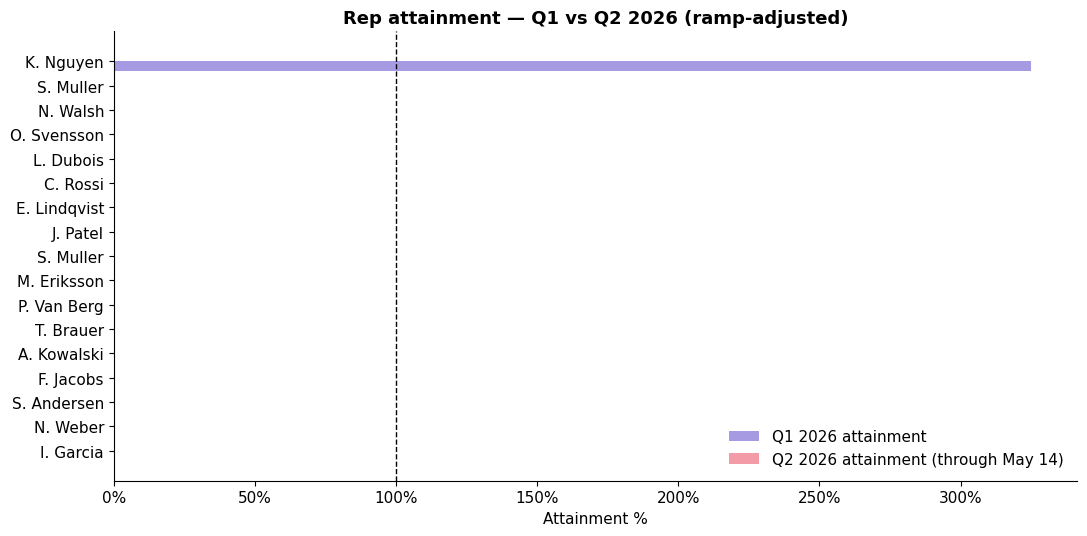

In [15]:
# Side-by-side Q1 vs Q2
merged = rep_q1.set_index('rep_id')[['rep_name','att_pct']].rename(columns={'att_pct':'q1_att'}).join(
    rep_q2.set_index('rep_id')[['att_pct']].rename(columns={'att_pct':'q2_att'})
).sort_values('q1_att', ascending=False).reset_index()
fig, ax = plt.subplots(figsize=(11, 5.5))
x = range(len(merged)); width = 0.4
ax.barh([i + width/2 for i in x], merged['q1_att'], height=width, color=PLEO['purple'], label='Q1 2026 attainment')
ax.barh([i - width/2 for i in x], merged['q2_att'], height=width, color=PLEO['pink'], label='Q2 2026 attainment (through May 14)')
ax.set_yticks(list(x)); ax.set_yticklabels(merged['rep_name'])
ax.axvline(100, color=PLEO['black'], linestyle='--', linewidth=1)
ax.set_title('Rep attainment — Q1 vs Q2 2026 (ramp-adjusted)')
ax.set_xlabel('Attainment %'); ax.legend(loc='lower right', frameon=False)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.invert_yaxis()
save_fig('rep_attainment_q1_q2')

## 6. Pipeline velocity — avg days per stage

From the pipeline snapshots, joined to the canonical stage so we don't double-count raw label variants.

In [16]:
velocity = q("""
  with cleaned as (
    select h.opportunity_id, h.stage_age_days, o.stage as stage
    from main_intermediate.int_pipeline_stage_history h
    join main_marts.fct_opportunities o using (opportunity_id)
    where h.stage_age_days > 0
  )
  select stage, round(avg(stage_age_days), 1) avg_age_days, count(distinct opportunity_id) opps
  from cleaned group by 1 order by avg_age_days desc
""")
velocity

,stage,avg_age_days,opps
0,Closed Won,105.5,12
1,Initial Meeting,82.7,4
2,Qualified,78.7,9
3,Contracting,78.6,3
4,Business Validation,74.8,11
5,Discovery,58.8,10
6,Negotiation,58.4,2
7,Evaluation,56.7,8


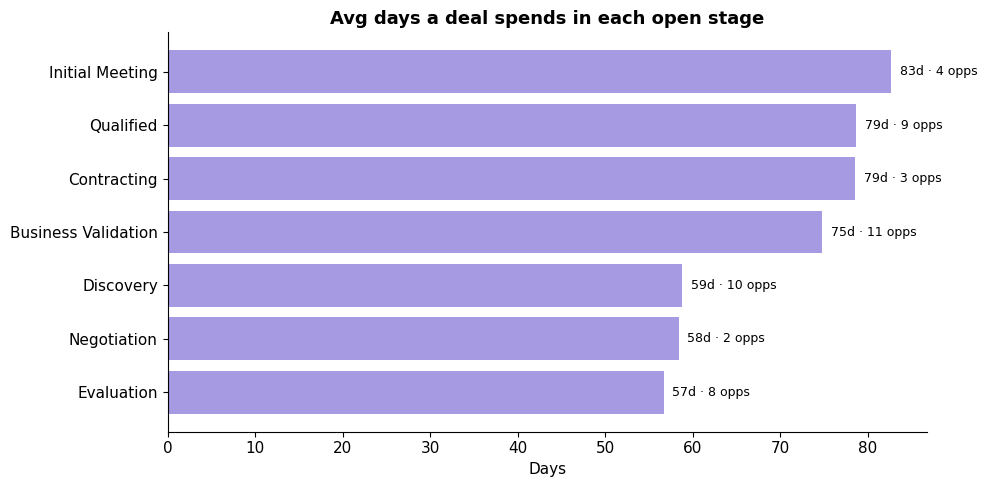

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
open_only = velocity[velocity['stage'] != 'Closed Won']
ax.barh(open_only['stage'], open_only['avg_age_days'], color=PLEO['purple'])
for i, v in enumerate(open_only['avg_age_days']):
    ax.text(v + 1, i, f'{v:.0f}d · {open_only["opps"].iloc[i]} opps', va='center', fontsize=9)
ax.set_title('Avg days a deal spends in each open stage')
ax.set_xlabel('Days')
ax.invert_yaxis()
save_fig('velocity_by_stage')

## 7. Pipeline efficiency — slippage and stage progression

In [18]:
slippage_trend = q("""
  select snapshot_month,
         count(*) filter (where close_date_slippage_days > 0) deals_slipped,
         count(*) total_deals,
         sum(arr_at_snapshot) filter (where close_date_slippage_days > 0)/1000 slipped_arr_keur
  from main_intermediate.int_pipeline_stage_history
  where snapshot_month >= date '2025-09-01'
  group by 1 order by 1
""")
slippage_trend['slip_rate'] = slippage_trend['deals_slipped'] / slippage_trend['total_deals'] * 100
slippage_trend

,snapshot_month,deals_slipped,total_deals,slipped_arr_keur,slip_rate
0,2025-09-01,0,1,NaN,0.000000
1,2026-01-01,0,3,NaN,0.000000
2,2026-02-01,1,34,13.0,2.941176
3,2026-03-01,4,43,241.0,9.302326
4,2026-04-01,8,53,183.0,15.094340
5,2026-05-01,9,47,405.0,19.148936


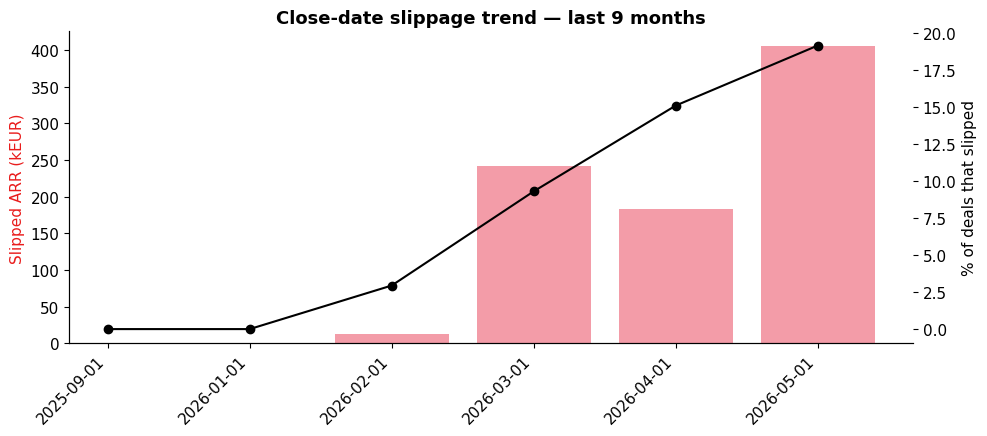

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(slippage_trend['snapshot_month'].astype(str), slippage_trend['slipped_arr_keur'], color=PLEO['pink'], label='Slipped ARR (kEUR)')
ax1.set_ylabel('Slipped ARR (kEUR)', color=PLEO['negative'])
ax2 = ax1.twinx()
ax2.plot(slippage_trend['snapshot_month'].astype(str), slippage_trend['slip_rate'], color=PLEO['black'], marker='o', label='Slip rate %')
ax2.set_ylabel('% of deals that slipped', color=PLEO['black'])
ax1.set_title('Close-date slippage trend — last 9 months')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
save_fig('slippage_trend')

## 8. Automation opportunity

In [20]:
stale_arr = q("select sum(arr_eur) a from main_marts.fct_pipeline_health where is_stale").iloc[0]['a']
win_rate = q("""
  select count(*) filter (where is_won)::double / nullif(count(*) filter (where is_won or is_lost), 0) wr
  from main_marts.fct_opportunities where opp_created_date >= date '2024-01-01'
""").iloc[0]['wr']
for re_rate in [0.10, 0.15, 0.20, 0.30]:
    print(f"  re-engage rate {re_rate*100:.0f}%, win rate {win_rate*100:.0f}% → recovered ARR €{stale_arr*re_rate*win_rate/1000:,.0f}K")

  re-engage rate 10%, win rate 22% → recovered ARR €29K
  re-engage rate 15%, win rate 22% → recovered ARR €44K
  re-engage rate 20%, win rate 22% → recovered ARR €59K
  re-engage rate 30%, win rate 22% → recovered ARR €88K


**Recommendation.** Stand up a weekly automated alert per AE listing their open opps with `days_since_last_activity >= 30`, copied to manager. Source already in `fct_pipeline_health.is_stale`. Conservative recovery at 15% re-engagement × 22% historical win rate = **+€44K ARR in 45 days**. Secondary recommendation: lock CRM picklists on segment/market/demand_source/stage — supported by the drift analysis below.

## 9. Data quality drift

In [21]:
drift = q("""
  select 'Accounts — market label drift' field, count(*) filter (where market_drift) drift_rows, count(*) total from main_marts.dim_accounts
  union all select 'Accounts — segment drift', count(*) filter (where segment_drift), count(*) from main_marts.dim_accounts
  union all select 'Accounts — country drift', count(*) filter (where country_drift), count(*) from main_marts.dim_accounts
  union all select 'Opportunities — stage drift', count(*) filter (where stage_drift), count(*) from main_marts.fct_opportunities
  union all select 'Opportunities — demand source drift', count(*) filter (where demand_source_drift), count(*) from main_marts.fct_opportunities
""")
drift

,field,drift_rows,total
0,Accounts — market label drift,2,40
1,Accounts — segment drift,0,40
2,Accounts — country drift,0,40
3,Opportunities — stage drift,0,129
4,Opportunities — demand source drift,0,129


## 10. Supporting — Cumulative ARR (no-churn view)

**Disclaimer.** This dataset has no churn or contract-cancellation events. The cumulative line below assumes every closed-won contract stays in the book forever. It is **supporting context**, not the headline — Pleo's brief (Assumptions R36) defines attainment as new closed-won ARR in the target period, which is what every other section measures.

What this view answers: *if no contracts churned, how large is our ARR book today?*

Ending ARR book today (no-churn assumption): €1,064K


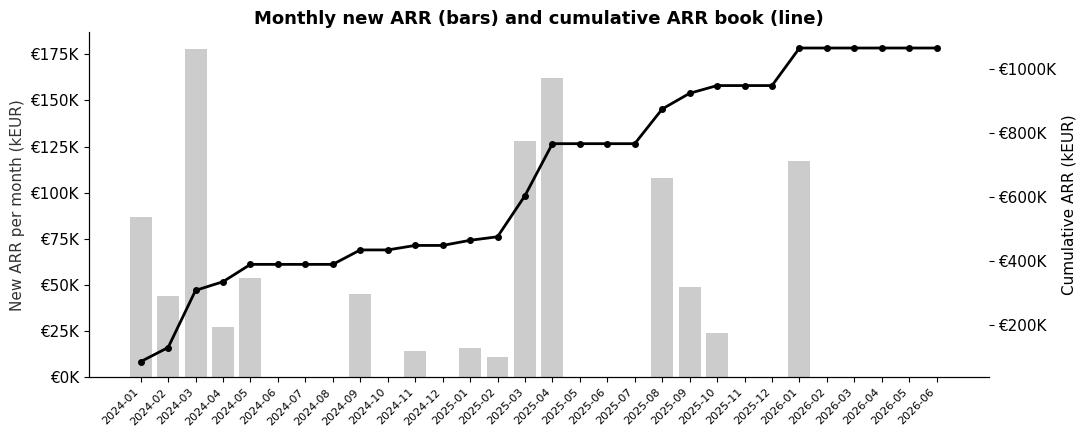

In [22]:
monthly = q("""
  select month, new_arr_eur, new_won_deals, cumulative_arr_eur
  from main_marts.fct_monthly_arr
  where month >= date '2024-01-01' and month <= date '2026-06-01'
  order by month
""")
today_book = monthly.loc[monthly['cumulative_arr_eur'].idxmax(), 'cumulative_arr_eur']
print(f"Ending ARR book today (no-churn assumption): €{today_book/1000:,.0f}K")

fig, ax1 = plt.subplots(figsize=(11, 4.5))
labels = monthly['month'].dt.strftime('%Y-%m')
ax1.bar(labels, monthly['new_arr_eur'] / 1000, color=PLEO['grey'], label='New ARR booked (kEUR)')
ax1.set_ylabel('New ARR per month (kEUR)', color=PLEO['text'])
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'€{v:.0f}K'))
ax2 = ax1.twinx()
ax2.plot(labels, monthly['cumulative_arr_eur'] / 1000, color=PLEO['black'], marker='o', markersize=4, linewidth=2, label='Cumulative ARR (no churn)')
ax2.set_ylabel('Cumulative ARR (kEUR)', color=PLEO['black'])
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'€{v:.0f}K'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax1.set_title('Monthly new ARR (bars) and cumulative ARR book (line)')
save_fig('cumulative_arr')

## 11. Action items (Monday morning)

| Action | Owner | EUR | Timeframe |
|---|---|---|---|
| Manager touch on Wise (€161K, 85d silent) | UKI lead | €161K at-risk | This week |
| UK Mid-Market stale re-engagement (6 deals, €296K) | UK Sales Lead | ~€10K recovered | 45 days |
| Stand up automated stale-deal alert | RevOps | +€44K recovered | 45 days from launch |
| Lock CRM picklists on segment/market/demand_source/stage | RevOps + Sales Ops | Analyst time saved | This sprint |
| Q2 RAG → RED, contingency review with Finance | CRO | €310K target | This week |